# Session 5: Unsupervised ML — Clustering Assets

## What we are learning today

In this session, we will group assets based on their behavior.

We will:
- download price data for multiple assets
- convert prices into returns
- engineer features like average return and volatility
- cluster assets using K-Means
- interpret clusters as risk groups

## Deliverable
- cluster labels for each asset
- short interpretation of each cluster (e.g., high risk, low risk)


# Why Are We Learning Unsupervised ML?

In the previous session, we worked on a prediction problem.

We created a target, built baselines, and measured how close our predictions were.

That type of machine learning is called **supervised learning** because we already know what answer we want the model to predict.

In this session, we are doing something different.

We are not trying to predict tomorrow’s price.

Instead, we are trying to find patterns in the data.

This is called **unsupervised machine learning**.

# Supervised vs Unsupervised Learning

## Supervised Learning

Supervised learning means we have a target.

Example:

> Use today’s stock data to predict tomorrow’s stock price.

There is a correct answer we can compare against.

## Unsupervised Learning

Unsupervised learning means we do not have a target.

Instead, we ask:

> Can the algorithm find groups or patterns by itself?

In this session, we will use unsupervised learning to group similar stocks together.

# Why Does This Matter in Finance?

In finance, we often want to understand how assets behave.

For example:

- Which stocks are stable?
- Which stocks are risky?
- Which stocks behave similarly?
- Which assets should or should not be grouped together in a portfolio?

Sometimes there is no simple “correct answer” column in the dataset.

That is why unsupervised learning is useful.

It helps us discover structure in financial data.

# What Are We Clustering?

Clustering means grouping similar items together.

In this notebook, each asset will be represented using features such as:

- average return
- volatility

Then we will use clustering to group assets that behave similarly.

For example:

- low return, low volatility assets may form one group
- high return, high volatility assets may form another group
- moderate assets may form another group

# 1. Load Data for Multiple Assets

We will use a small basket of stocks.

Each column will represent one asset.


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA"]

data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]

data.head()


/tmp/ipykernel_24444/2070429045.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", progress=False)["Close"]


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA,TSLA
Date,,,,,,
2022-01-03,178.103668,170.404495,143.802963,323.160828,30.061140,399.926666
2022-01-04,175.843231,167.522003,143.215805,317.619537,29.231787,383.196655
2022-01-05,171.165802,164.356995,136.645615,305.426727,27.549143,362.706665
2022-01-06,168.308502,163.253998,136.618332,303.013336,28.122000,354.899994
2022-01-07,168.474869,162.554001,135.893860,303.167755,27.192850,342.320007


## Practice 1

Add 2 more assets of your choice to the ticker list.

Tasks:
- update the ticker list
- reload the data
- display the first 5 rows


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Stock_name = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "DIS", "KO", "WMT"]

Stock_data = yf.download(Stock_name, start="2022-01-01", progress=False)["Close"]

Stock_data.head()


/tmp/ipykernel_24444/1403772675.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Stock_data = yf.download(Stock_name, start="2022-01-01", progress=False)["Close"]


Ticker,AAPL,AMZN,DIS,GOOGL,KO,MSFT,NVDA,TSLA,WMT
Date,,,,,,,,,
2022-01-03,178.103668,170.404495,153.153320,143.802979,52.267666,323.160797,30.061136,399.926666,45.671684
2022-01-04,175.843262,167.522003,152.147034,143.215836,53.140263,317.619537,29.231791,383.196655,44.834969
2022-01-05,171.165817,164.356995,151.619446,136.645630,53.580971,305.426727,27.549145,362.706665,45.441196
2022-01-06,168.308517,163.253998,153.290100,136.618332,53.298912,303.013367,28.122002,354.899994,45.314896
2022-01-07,168.474838,162.554001,154.198700,135.893829,53.175518,303.167755,27.192848,342.320007,45.747459


# 2. Convert Prices to Returns

Raw prices are not ideal for comparison.

We convert prices to returns using percentage change.

Return tells us how much the price changed relative to the previous day.


In [3]:
returns = data.pct_change().dropna()

returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA,TSLA
Date,,,,,,
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147,-0.027589,-0.041833
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388,-0.057562,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902,0.020794,-0.021523
2022-01-07,0.000988,-0.004288,-0.005303,0.000510,-0.033040,-0.035447
2022-01-10,0.000116,-0.006570,0.012060,0.000733,0.005615,0.030342


## Practice 2

Check your understanding of returns.

Tasks:
- display the first 5 rows
- display the shape of the returns dataframe


In [4]:
Stock_returns = Stock_data.pct_change().dropna()

Stock_returns.head()

Ticker,AAPL,AMZN,DIS,GOOGL,KO,MSFT,NVDA,TSLA,WMT
Date,,,,,,,,,
2022-01-04,-0.012692,-0.016916,-0.006570,-0.004083,0.016695,-0.017147,-0.027589,-0.041833,-0.018320
2022-01-05,-0.026600,-0.018893,-0.003468,-0.045876,0.008293,-0.038388,-0.057562,-0.053471,0.013521
2022-01-06,-0.016693,-0.006711,0.011019,-0.000200,-0.005264,-0.007902,0.020794,-0.021523,-0.002779
2022-01-07,0.000988,-0.004288,0.005927,-0.005303,-0.002315,0.000510,-0.033040,-0.035447,0.009546
2022-01-10,0.000116,-0.006570,-0.007793,0.012061,0.001658,0.000732,0.005615,0.030342,-0.001932


# 3. Feature Engineering

To cluster assets, we need features.

We will create:
- average return (mean)
- volatility (standard deviation)

Each asset becomes one row with these features.


In [ ]:
features = pd.DataFrame({
    "mean_return": returns.mean(),
    "volatility": returns.std()
})

features


,mean_return,volatility
Ticker,,
AAPL,0.000575,0.017808
AMZN,0.000689,0.023293
GOOGL,0.001119,0.020503
MSFT,0.000377,0.017220
NVDA,0.002287,0.033225
TSLA,0.000697,0.038013


## Practice 3

Create the features dataframe yourself.

Tasks:
- compute mean return
- compute volatility
- combine into a dataframe
- display the result


In [5]:
Stock_features = pd.DataFrame({
    "mean_return": Stock_returns.mean(),
    "volatility": Stock_returns.std()
})

Stock_features

,mean_return,volatility
Ticker,,
AAPL,0.000575,0.017808
AMZN,0.000689,0.023293
DIS,-0.000186,0.018867
GOOGL,0.001119,0.020503
KO,0.000428,0.010253
MSFT,0.000377,0.017220
NVDA,0.002287,0.033225
TSLA,0.000697,0.038013
WMT,0.001073,0.013942


# 4. Visualize the Features

We plot assets using:
- x-axis: volatility
- y-axis: mean return

This helps us understand the spread before clustering.


/tmp/ipykernel_2710/4272146867.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (features["volatility"][i], features["mean_return"][i]))


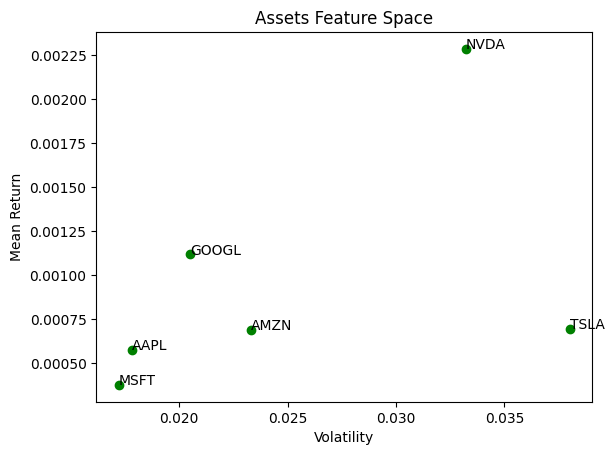

In [ ]:
plt.figure()
plt.scatter(features["volatility"], features["mean_return"],c='green')

for i, txt in enumerate(features.index):
    plt.annotate(txt, (features["volatility"][i], features["mean_return"][i]))

plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.title("Assets Feature Space")
plt.show()


## Practice 4

Create your own scatter plot for the features.

Tasks:
- plot volatility vs mean return
- label each point with the ticker name


/tmp/ipykernel_24444/4162083683.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (Stock_features["volatility"][i], Stock_features["mean_return"][i]))


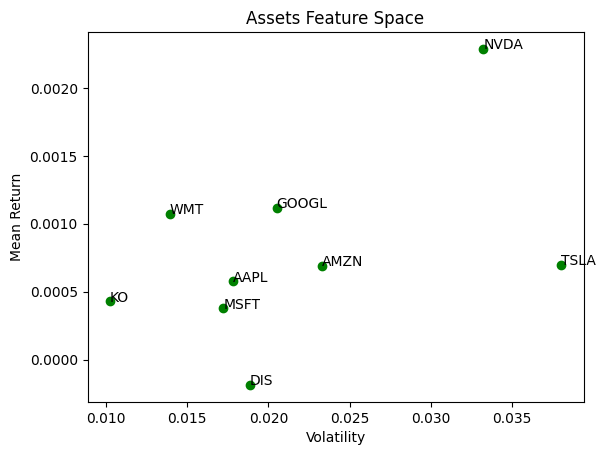

In [6]:
plt.figure()
plt.scatter(Stock_features["volatility"], Stock_features["mean_return"],c='green')

for i, txt in enumerate(Stock_features.index):
    plt.annotate(txt, (Stock_features["volatility"][i], Stock_features["mean_return"][i]))

plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.title("Assets Feature Space")
plt.show()


# 5. Apply K-Means Clustering

We now group assets into clusters.

We will use K-Means with k = 3 clusters.


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(features)

features


NameError: name 'features' is not defined

## Practice 5

Run K-Means yourself.

Tasks:
- create a KMeans model with 3 clusters
- fit it on the features
- store cluster labels in a column called `cluster`


In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
Stock_features["cluster"] = kmeans.fit_predict(Stock_features)

Stock_features


,mean_return,volatility,cluster
Ticker,,,
AAPL,0.000575,0.017808,0
AMZN,0.000689,0.023293,0
DIS,-0.000186,0.018867,0
GOOGL,0.001119,0.020503,0
KO,0.000428,0.010253,2
MSFT,0.000377,0.017220,0
NVDA,0.002287,0.033225,1
TSLA,0.000697,0.038013,1
WMT,0.001073,0.013942,2


# 6. Visualize Clusters

We now color each asset by its cluster.


/tmp/ipykernel_2710/2581378972.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (features["volatility"][i], features["mean_return"][i]))


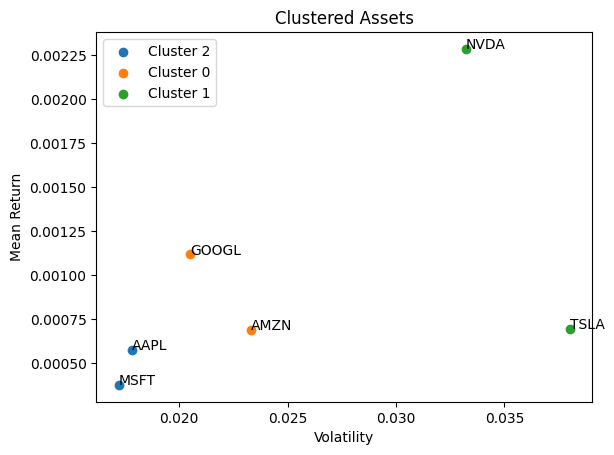

In [ ]:
plt.figure()

for cluster in features["cluster"].unique():
    subset = features[features["cluster"] == cluster]
    plt.scatter(subset["volatility"], subset["mean_return"], label=f"Cluster {cluster}")

for i, txt in enumerate(features.index):
    plt.annotate(txt, (features["volatility"][i], features["mean_return"][i]))

plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.legend()
plt.title("Clustered Assets")
plt.show()


## Practice 6

Plot the clustered assets yourself.

Tasks:
- plot each cluster with a different color
- label each asset


/tmp/ipykernel_24444/560667994.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (Stock_features["volatility"][i], Stock_features["mean_return"][i]))


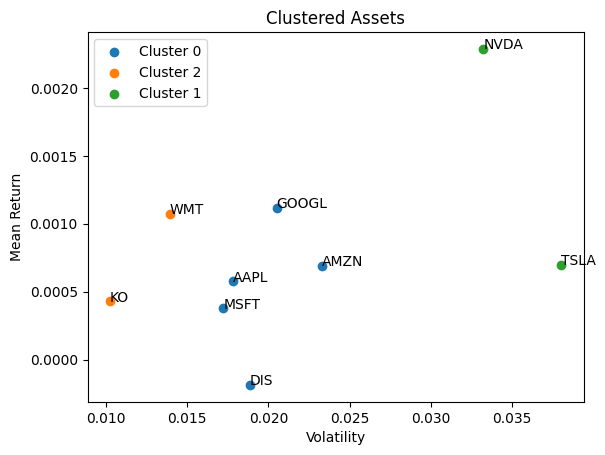

In [13]:
plt.figure()

for cluster in Stock_features["cluster"].unique():
    subset = Stock_features[Stock_features["cluster"] == cluster]
    plt.scatter(subset["volatility"], subset["mean_return"], label=f"Cluster {cluster}")

for i, txt in enumerate(Stock_features.index):
    plt.annotate(txt, (Stock_features["volatility"][i], Stock_features["mean_return"][i]))

plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.legend()
plt.title("Clustered Assets")
plt.show()

# 7. Interpret the Clusters

Now we interpret what each cluster means.

Typical interpretations:
- High volatility → high risk
- Low volatility → low risk
- High return + high volatility → aggressive assets
- Low return + low volatility → stable assets


## Practice 7

Interpret the clusters.

Tasks:
- group assets by cluster
- print assets in each cluster
- write 1–2 lines describing each cluster


In [ ]:
# Your code here


# 8. Final Output

You should now have:

- a dataframe with cluster labels
- a visualization of clustered assets
- an interpretation of each cluster

## What to commit

- features dataframe (with clusters)
- short write-up explaining clusters


In [ ]:
# Optional: display final table
features
